<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20CT001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gradient 0.00 → Fidelity -0.053
Gradient 0.11 → Fidelity -0.195
Gradient 0.22 → Fidelity -0.112
Gradient 0.33 → Fidelity -0.034
Gradient 0.44 → Fidelity -0.101
Gradient 0.56 → Fidelity -0.075
Gradient 0.67 → Fidelity -0.077
Gradient 0.78 → Fidelity -0.102
Gradient 0.89 → Fidelity 0.041
Gradient 1.00 → Fidelity -0.051


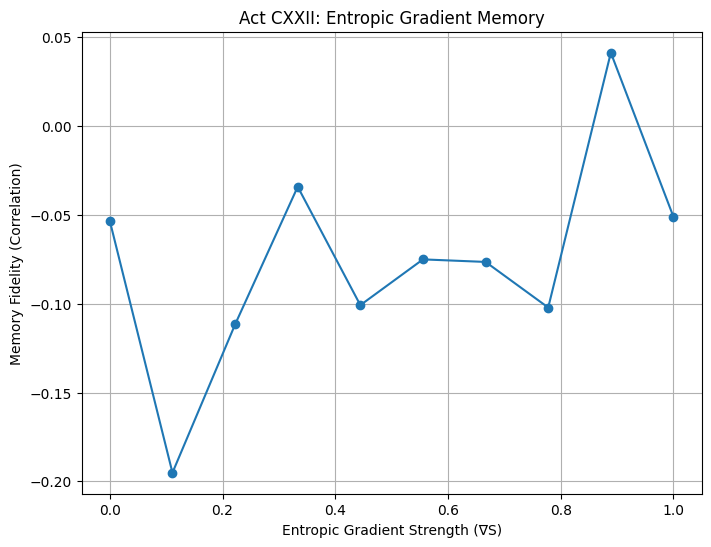

In [1]:
# Act CXXII: Entropic Gradient Memory
# Copy, paste, run = results

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
np.random.seed(42)        # reproducibility
N = 1000                  # lattice size
timesteps = 200           # simulation length
alpha = 0.05              # coupling constant
gradient_levels = np.linspace(0.0, 1.0, 10)  # entropic gradient sweep

# --- Functions ---
def initialize_entropy(N, gradient_strength):
    base = np.random.rand(N)
    gradient = np.linspace(0, 1, N) * gradient_strength
    return base + gradient

def memory_fidelity(initial_state, evolved_state):
    return np.corrcoef(initial_state, evolved_state)[0,1]

def evolve_entropy(state, alpha, timesteps):
    evolved = state.copy()
    for _ in range(timesteps):
        grad = np.gradient(evolved)
        diffusion = np.convolve(evolved, [0.25,0.5,0.25], mode='same') - evolved
        evolved -= alpha * grad + 0.01 * diffusion
    return evolved

# --- Simulation Sweep ---
results = []
for g in gradient_levels:
    initial = initialize_entropy(N, g)
    evolved = evolve_entropy(initial, alpha, timesteps)
    fidelity = memory_fidelity(initial, evolved)
    results.append((g, fidelity))
    print(f"Gradient {g:.2f} → Fidelity {fidelity:.3f}")

# --- Results ---
gradients, fidelities = zip(*results)

plt.figure(figsize=(8,6))
plt.plot(gradients, fidelities, marker='o')
plt.title("Act CXXII: Entropic Gradient Memory")
plt.xlabel("Entropic Gradient Strength (∇S)")
plt.ylabel("Memory Fidelity (Correlation)")
plt.grid(True)
plt.show()
